In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('images', exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [3]:
campaigns = pd.read_csv('data/campaigns.csv')
platforms = pd.read_csv('data/platforms.csv')
campaign_types = pd.read_csv('data/campaign_types.csv')

print("Data loaded.")

Data loaded.


In [4]:
# Create copy for analysis
df = campaigns.copy()

# Calculate funnel metrics
df['CTR'] = df['Clicks'] / df['Impressions']
df['CPC'] = df['Cost'] / df['Clicks'].replace(0, np.nan)
df['CPM'] = (df['Cost'] / df['Impressions']) * 1000
df['CVR'] = df['Conversions'] / df['Clicks'].replace(0, np.nan)
df['CPA'] = df['Cost'] / df['Conversions'].replace(0, np.nan)
df['ROAS'] = df['Revenue'] / df['Cost'].replace(0, np.nan)

# Funnel rates
df['ImpressionToClickRate'] = df['CTR']
df['ClickToConversionRate'] = df['CVR']
df['ImpressionToConversionRate'] = df['Conversions'] / df['Impressions']

print("KPIs calculated.")

KPIs calculated.


In [5]:
# Calculate total funnel metrics
total_impressions = df['Impressions'].sum()
total_clicks = df['Clicks'].sum()
total_conversions = df['Conversions'].sum()
total_revenue = df['Revenue'].sum()
total_cost = df['Cost'].sum()

print("Overall Funnel")
print("-" * 40)
print(f"Impressions:  {total_impressions:,}")
print(f"Clicks:       {total_clicks:,}")
print(f"Conversions:  {total_conversions:,}")
print(f"Revenue:      ${total_revenue:,.2f}")
print(f"Cost:         ${total_cost:,.2f}")

print("\nFunnel Conversion Rates:")
print(f"Impressions → Clicks (CTR):     {total_clicks/total_impressions*100:.2f}%")
print(f"Clicks → Conversions (CVR):     {total_conversions/total_clicks*100:.2f}%")
print(f"Impressions → Conversions:      {total_conversions/total_impressions*100:.4f}%")
print(f"Average Revenue per Conversion: ${total_revenue/total_conversions:.2f}")

Overall Funnel
----------------------------------------
Impressions:  14,960,307,643
Clicks:       295,677,450
Conversions:  16,051,757
Revenue:      $1,774,050,606.45
Cost:         $614,839,603.15

Funnel Conversion Rates:
Impressions → Clicks (CTR):     1.98%
Clicks → Conversions (CVR):     5.43%
Impressions → Conversions:      0.1073%
Average Revenue per Conversion: $110.52


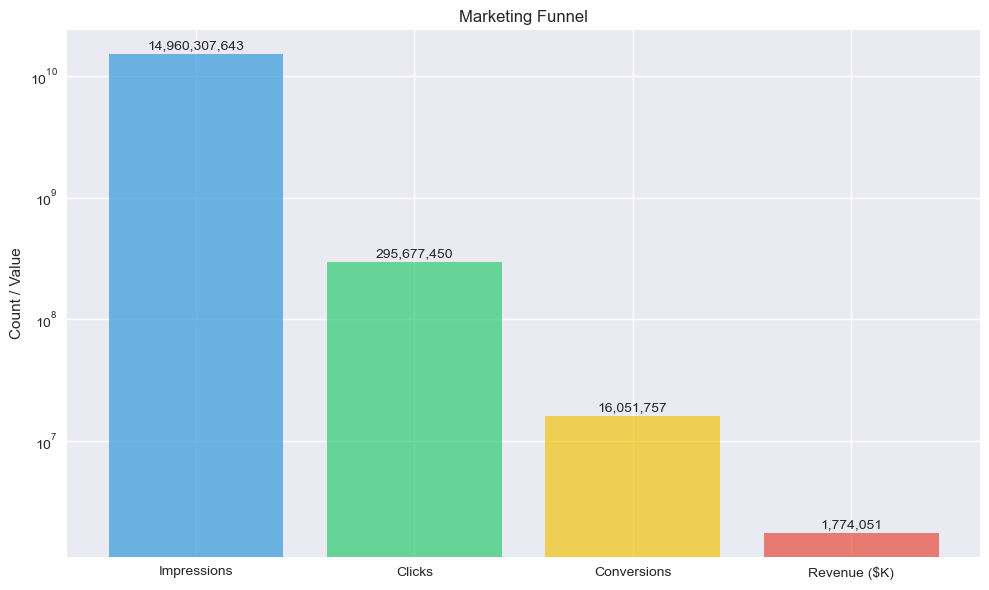

In [6]:
# Create funnel chart
fig, ax = plt.subplots(figsize=(10, 6))

funnel_data = [
    total_impressions,
    total_clicks,
    total_conversions,
    total_revenue / 1000
]

funnel_labels = ['Impressions', 'Clicks', 'Conversions', 'Revenue ($K)']
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e74c3c']

bars = ax.bar(funnel_labels, funnel_data, color=colors, alpha=0.7)
ax.set_title('Marketing Funnel')
ax.set_ylabel('Count / Value')
ax.set_yscale('log')

# Add values on bars
for bar, val in zip(bars, funnel_data):
    if 'Revenue' in bar.get_label():
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
                f'${val:,.0f}K', ha='center', fontsize=10)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
                f'{val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/funnel_overall.png', dpi=300)
plt.show()

In [7]:
# Merge with platforms
df_platform = df.merge(platforms, on='PlatformID')

# Calculate funnel metrics by platform
platform_funnel = df_platform.groupby('PlatformName').agg({
    'Impressions': 'sum',
    'Clicks': 'sum',
    'Conversions': 'sum',
    'Revenue': 'sum',
    'Cost': 'sum'
}).round(2)

platform_funnel['CTR'] = platform_funnel['Clicks'] / platform_funnel['Impressions'] * 100
platform_funnel['CVR'] = platform_funnel['Conversions'] / platform_funnel['Clicks'] * 100
platform_funnel['CPA'] = platform_funnel['Cost'] / platform_funnel['Conversions']
platform_funnel['ROAS'] = platform_funnel['Revenue'] / platform_funnel['Cost']

print("Funnel by Platform")
print("-" * 40)
print(platform_funnel[['CTR', 'CVR', 'CPA', 'ROAS']].to_string())

Funnel by Platform
----------------------------------------
                   CTR       CVR        CPA      ROAS
PlatformName                                         
Facebook      1.477318  5.178434  23.443419  2.695501
Google Ads    3.004880  5.616152  44.702890  3.100680
Instagram     1.978173  5.342369  33.965569  2.822313
LinkedIn      0.795559  5.461737  90.478189  2.445406
TikTok        2.523471  5.477183  27.561718  2.930585
X (Twitter)   1.218121  5.304848  19.045835  2.547372
YouTube       1.818981  5.297586  56.564672  2.823225


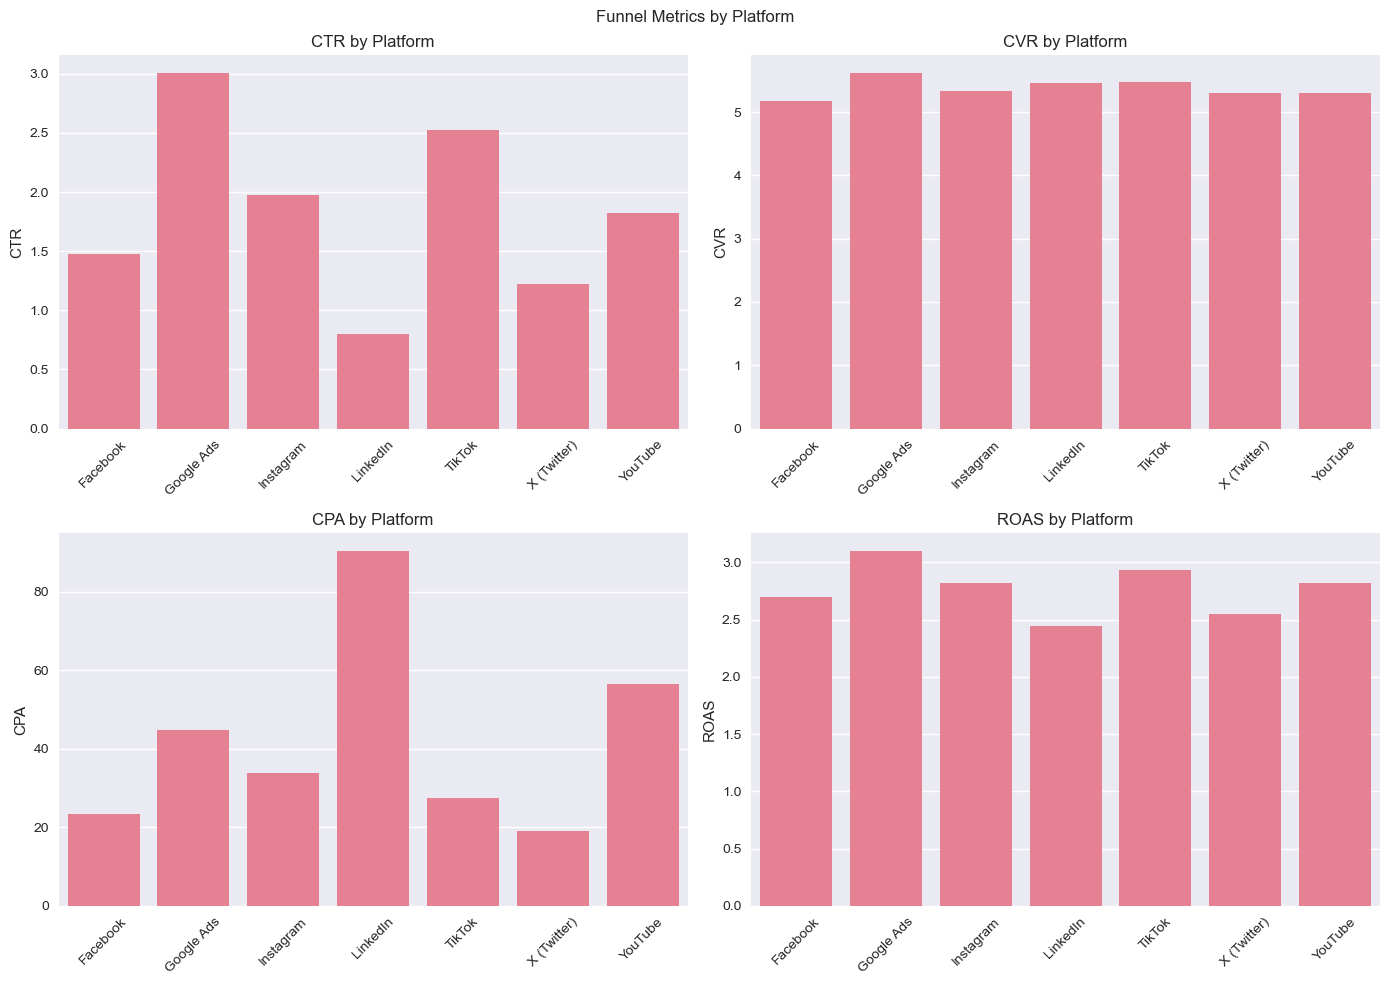

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Funnel Metrics by Platform')

# CTR by Platform
sns.barplot(data=platform_funnel.reset_index(), x='PlatformName', y='CTR', ax=axes[0, 0])
axes[0, 0].set_title('CTR by Platform')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# CVR by Platform
sns.barplot(data=platform_funnel.reset_index(), x='PlatformName', y='CVR', ax=axes[0, 1])
axes[0, 1].set_title('CVR by Platform')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# CPA by Platform
sns.barplot(data=platform_funnel.reset_index(), x='PlatformName', y='CPA', ax=axes[1, 0])
axes[1, 0].set_title('CPA by Platform')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

# ROAS by Platform
sns.barplot(data=platform_funnel.reset_index(), x='PlatformName', y='ROAS', ax=axes[1, 1])
axes[1, 1].set_title('ROAS by Platform')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/funnel_by_platform.png', dpi=300)
plt.show()

In [9]:
print("Platform Funnel Diagnostics")
print("-" * 40)

for platform in platform_funnel.index:
    ctr = platform_funnel.loc[platform, 'CTR']
    cvr = platform_funnel.loc[platform, 'CVR']
    cpa = platform_funnel.loc[platform, 'CPA']
    roas = platform_funnel.loc[platform, 'ROAS']
    
    print(f"\n{platform}:")
    print(f"  CTR: {ctr:.2f}%")
    print(f"  CVR: {cvr:.2f}%")
    print(f"  CPA: ${cpa:.2f}")
    print(f"  ROAS: {roas:.2f}x")
    
    # Diagnose issues
    if ctr < 1.0:
        print("  Issue: Low CTR → Creative/Targeting problem")
    elif cvr < 5.0:
        print("  Issue: Low CVR → Landing page/Offer problem")
    elif cpa > 50:
        print("  Issue: High CPA → Efficiency problem")
    elif roas < 2.5:
        print("  Issue: Low ROAS → Revenue efficiency problem")
    else:
        print("  Status: No major funnel issues detected")

Platform Funnel Diagnostics
----------------------------------------

Facebook:
  CTR: 1.48%
  CVR: 5.18%
  CPA: $23.44
  ROAS: 2.70x
  Status: No major funnel issues detected

Google Ads:
  CTR: 3.00%
  CVR: 5.62%
  CPA: $44.70
  ROAS: 3.10x
  Status: No major funnel issues detected

Instagram:
  CTR: 1.98%
  CVR: 5.34%
  CPA: $33.97
  ROAS: 2.82x
  Status: No major funnel issues detected

LinkedIn:
  CTR: 0.80%
  CVR: 5.46%
  CPA: $90.48
  ROAS: 2.45x
  Issue: Low CTR → Creative/Targeting problem

TikTok:
  CTR: 2.52%
  CVR: 5.48%
  CPA: $27.56
  ROAS: 2.93x
  Status: No major funnel issues detected

X (Twitter):
  CTR: 1.22%
  CVR: 5.30%
  CPA: $19.05
  ROAS: 2.55x
  Status: No major funnel issues detected

YouTube:
  CTR: 1.82%
  CVR: 5.30%
  CPA: $56.56
  ROAS: 2.82x
  Issue: High CPA → Efficiency problem


In [10]:
# Calculate benchmarks
median_ctr = df['CTR'].median()
median_cvr = df['CVR'].median()
median_cpa = df['CPA'].median()
median_roas = df['ROAS'].median()

print("Campaign Benchmarks:")
print("-" * 40)
print(f"Median CTR:  {median_ctr*100:.2f}%")
print(f"Median CVR:  {median_cvr*100:.2f}%")
print(f"Median CPA:  ${median_cpa:.2f}")
print(f"Median ROAS: {median_roas:.2f}x")

Campaign Benchmarks:
----------------------------------------
Median CTR:  1.70%
Median CVR:  5.25%
Median CPA:  $37.62
Median ROAS: 2.84x


In [11]:
def diagnose_campaign(row):
    """Diagnose campaign performance issues"""
    diagnosis = []
    
    # CTR problem
    if row['CTR'] < median_ctr * 0.5:
        diagnosis.append('Low CTR (Creative/Targeting Issue)')
    elif row['CTR'] > median_ctr * 1.5:
        diagnosis.append('High CTR (Good Creative/Targeting)')
    
    # CVR problem
    if row['CVR'] < median_cvr * 0.5:
        diagnosis.append('Low CVR (Landing Page/Offer Issue)')
    elif row['CVR'] > median_cvr * 1.5:
        diagnosis.append('High CVR (Good Post-Click Experience)')
    
    # CPA problem
    if row['CPA'] > median_cpa * 2:
        diagnosis.append('High CPA (Efficiency Problem)')
    elif row['CPA'] < median_cpa * 0.5:
        diagnosis.append('Low CPA (Efficient)')
    
    # ROAS problem
    if row['ROAS'] < 1.0:
        diagnosis.append('Negative ROI (Unprofitable)')
    elif row['ROAS'] > median_roas * 1.5:
        diagnosis.append('High ROAS (Profitable)')
    
    # Funnel position
    if row['CTR'] < median_ctr and row['CVR'] > median_cvr:
        diagnosis.append('Funnel Issue: Top of Funnel (Creative/Targeting)')
    elif row['CTR'] > median_ctr and row['CVR'] < median_cvr:
        diagnosis.append('Funnel Issue: Bottom of Funnel (Landing Page/Offer)')
    elif row['CTR'] < median_ctr and row['CVR'] < median_cvr:
        diagnosis.append('Funnel Issue: Full Funnel (Everything)')
    elif row['CTR'] > median_ctr and row['CVR'] > median_cvr:
        diagnosis.append('Funnel Position: Strong (Scale Candidate)')
    
    return ', '.join(diagnosis) if diagnosis else 'Healthy Campaign'

df['Diagnosis'] = df.apply(diagnose_campaign, axis=1)

print("Campaign Diagnosis Complete.")
print(f"Total campaigns diagnosed: {len(df):,}")

Campaign Diagnosis Complete.
Total campaigns diagnosed: 10,000


In [12]:
# Count diagnoses
diagnosis_counts = df['Diagnosis'].value_counts()

print("Diagnosis Distribution")
print("-" * 40)
print(diagnosis_counts.head(10).to_string())

Diagnosis Distribution
----------------------------------------
Diagnosis
Funnel Issue: Full Funnel (Everything)                                                                       1642
Funnel Position: Strong (Scale Candidate)                                                                    1389
High CTR (Good Creative/Targeting), Funnel Position: Strong (Scale Candidate)                                1371
Funnel Issue: Bottom of Funnel (Landing Page/Offer)                                                          1108
Funnel Issue: Top of Funnel (Creative/Targeting)                                                              573
Low CPA (Efficient), Funnel Issue: Top of Funnel (Creative/Targeting)                                         539
Low CTR (Creative/Targeting Issue), High CPA (Efficiency Problem), Funnel Issue: Full Funnel (Everything)     536
High CTR (Good Creative/Targeting), Funnel Issue: Bottom of Funnel (Landing Page/Offer)                       410
High CPA (Effi

In [13]:
def calculate_health_score(row):
    """Calculate campaign health score (0-100)"""
    score = 0
    
    # CTR (20 points)
    if row['CTR'] > median_ctr * 1.5:
        score += 20
    elif row['CTR'] > median_ctr:
        score += 15
    elif row['CTR'] > median_ctr * 0.5:
        score += 10
    else:
        score += 5
    
    # CVR (20 points)
    if row['CVR'] > median_cvr * 1.5:
        score += 20
    elif row['CVR'] > median_cvr:
        score += 15
    elif row['CVR'] > median_cvr * 0.5:
        score += 10
    else:
        score += 5
    
    # CPA (20 points)
    if row['CPA'] < median_cpa * 0.5:
        score += 20
    elif row['CPA'] < median_cpa:
        score += 15
    elif row['CPA'] < median_cpa * 1.5:
        score += 10
    else:
        score += 5
    
    # ROAS (20 points)
    if row['ROAS'] > median_roas * 1.5:
        score += 20
    elif row['ROAS'] > median_roas:
        score += 15
    elif row['ROAS'] > 1.0:
        score += 10
    else:
        score += 5
    
    # Volume (20 points)
    if row['Conversions'] > 100:
        score += 20
    elif row['Conversions'] > 50:
        score += 15
    elif row['Conversions'] > 20:
        score += 10
    else:
        score += 5
    
    return min(100, score)

df['Health_Score'] = df.apply(calculate_health_score, axis=1)

print("Health Scores Calculated.")
print(f"Mean Health Score: {df['Health_Score'].mean():.1f}")
print(f"Median Health Score: {df['Health_Score'].median():.0f}")

Health Scores Calculated.
Mean Health Score: 68.6
Median Health Score: 70


In [14]:
def health_category(score):
    if score >= 80:
        return 'Excellent'
    elif score >= 60:
        return 'Good'
    elif score >= 40:
        return 'Fair'
    else:
        return 'Poor'

df['Health_Category'] = df['Health_Score'].apply(health_category)

health_counts = df['Health_Category'].value_counts()

print("Health Categories")
print("-" * 40)
for category, count in health_counts.items():
    pct = count / len(df) * 100
    print(f"{category}: {count:,} ({pct:.1f}%)")

Health Categories
----------------------------------------
Good: 6,044 (60.4%)
Excellent: 2,361 (23.6%)
Fair: 1,546 (15.5%)
Poor: 49 (0.5%)


In [15]:
# Identify retargeting candidates
retargeting_criteria = (
    (df['CTR'] > median_ctr) &
    (df['CVR'] < median_cvr) &
    (df['Impressions'] > 5000) &
    (df['Clicks'] > 100) &
    (df['ROAS'] < 2.0)
)

retargeting_candidates = df[retargeting_criteria].copy()

print("Retargeting Opportunities")
print("-" * 40)
print(f"Candidates: {len(retargeting_candidates)} campaigns")
print(f"Total Non-Converting Clicks: {(retargeting_candidates['Clicks'] - retargeting_candidates['Conversions']).sum():,.0f}")
print(f"Average CTR: {retargeting_candidates['CTR'].mean()*100:.2f}%")
print(f"Average CVR: {retargeting_candidates['CVR'].mean()*100:.2f}%")

Retargeting Opportunities
----------------------------------------
Candidates: 214 campaigns
Total Non-Converting Clicks: 8,530,537
Average CTR: 2.26%
Average CVR: 4.52%


In [16]:
# Show top retargeting candidates
top_retarget = retargeting_candidates.nlargest(10, 'Impressions')[['CampaignID', 'PlatformID', 'CampaignTypeID', 
                                                                    'CTR', 'CVR', 'Impressions', 'Clicks', 'Conversions', 'ROAS']]

print("Top Retargeting Candidates")
print("-" * 40)
print(top_retarget.to_string(index=False))

Top Retargeting Candidates
----------------------------------------
CampaignID  PlatformID  CampaignTypeID      CTR      CVR  Impressions  Clicks  Conversions     ROAS
 CAM001071           1               5 0.023435 0.040760     12363881  289746        11810 1.707551
 CAM005243           1               4 0.028412 0.040993      7130641  202598         8305 0.935524
 CAM004167           3               2 0.020081 0.052227      7079667  142169         7425 1.059079
 CAM003755           2               5 0.017507 0.050075      5811750  101747         5095 0.962541
 CAM009608           2               4 0.023076 0.036588      5513579  127229         4655 1.425445
 CAM004919           2               4 0.024862 0.041638      5502246  136798         5696 1.586913
 CAM003435           1               5 0.027805 0.049538      5425403  150854         7473 1.174109
 CAM001569           3               2 0.025720 0.051944      5377245  138304         7184 1.690512
 CAM003052           4          

In [18]:
print("Funnel & Diagnostics Summary")
print("-" * 40)

print("\nOverall Funnel:")
print(f"  Impressions → Clicks: {total_clicks/total_impressions*100:.2f}%")
print(f"  Clicks → Conversions: {total_conversions/total_clicks*100:.2f}%")
print(f"  Impressions → Conversions: {total_conversions/total_impressions*100:.4f}%")

print("\nHealth Categories:")
for category, count in health_counts.items():
    pct = count / len(df) * 100
    print(f"  {category}: {count:,} ({pct:.1f}%)")

print(f"\nRetargeting Opportunities: {len(retargeting_candidates)} campaigns")
print(f"  Total non-converting clicks: {(retargeting_candidates['Clicks'] - retargeting_candidates['Conversions']).sum():,.0f}")

Funnel & Diagnostics Summary
----------------------------------------

Overall Funnel:
  Impressions → Clicks: 1.98%
  Clicks → Conversions: 5.43%
  Impressions → Conversions: 0.1073%

Health Categories:
  Good: 6,044 (60.4%)
  Excellent: 2,361 (23.6%)
  Fair: 1,546 (15.5%)
  Poor: 49 (0.5%)

Retargeting Opportunities: 214 campaigns
  Total non-converting clicks: 8,530,537
